In [34]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_openai import ChatOpenAI
from langchain_classic.chains.combine_documents.reduce import acollapse_docs,split_list_of_docs
from langgraph.constants import Send
from langgraph.graph import START,END,StateGraph
import operator
from typing import List, Literal,TypedDict,Annotated
from dotenv import load_dotenv
from transformers import pipeline,AutoModelForSeq2SeqLM
import os


/var/folders/yy/vn34dksd7833mq21mhhztxvm0000gn/T/ipykernel_14806/1655388851.py:7: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [23]:
load_dotenv()

True

In [33]:

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
token = os.getenv("HF_TOKEN")

In [36]:
llm = ChatOpenAI(model="gpt-4o-mini",temperature=0.2)

In [35]:

# Model choice: Pegasus is specifically designed for summarization
model_id = "google/pegasus-xsum"
summarizer = AutoModelForSeq2SeqLM.from_pretrained(model_id, token=token)


Loading weights: 100%|██████████| 680/680 [00:00<00:00, 13437.65it/s]
[transformers] PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.encoder.embed_positions.weight | MISSING | 
model.decoder.embed_positions.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
llm.invoke("hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_11121efef4', 'id': 'chatcmpl-DafIe1yIcDx5utmqTZNYDcShtFCml', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019de30e-e7b8-78b3-bb65-46ace22cae00-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [39]:
## create map reduce prompt
map_prompt = ChatPromptTemplate.from_messages(
    [('system','Write a concise summary of the following:\n\n {context}')]
)
reduce_prompt_template = """
The following is a set of summaries:
{docs}
Take these and distill it into a final consolidated summary.
"""

reduce_prompt = ChatPromptTemplate.from_messages(
    [('user',reduce_prompt_template)]
)


In [41]:
## load the document

file_path = "data/2302.pdf"
loader = PyPDFLoader(file_path)
docs = loader.load()
len(docs)


27

In [88]:
## define the max token in the summarization

token_max = 2000
class OverAllState(TypedDict):
    ## consist of all the states of the graph for summarization
    contents : List[str]
    summaries: Annotated[list,operator.add]
    collapsed_summaries: List[Document]
    final_summary:str

class SummaryState(TypedDict):
    content:str


# function to generate summary

async def generate_summary(state: SummaryState):
    prompt = map_prompt.invoke(state['content'])
    response = await llm.ainvoke(prompt)
    return {"summaries":[response.content]}

## function to map the summaries to the function
def map_summaries(state:OverAllState):
    return [Send("generate_summary",{"content":content})for content in state['contents']]


## function to collect the summaries and collapse them if they are too long
def collect_summaries(state:OverAllState):
    return {"collapsed_summaries":[Document(summary) for summary in state['summaries']]}


## function to reduce the summary
async def reduce_summary(input_dict:dict) -> str:
    prompt = reduce_prompt.invoke(input_dict)
    response = await llm.ainvoke(prompt)
    return response.content


def length_function(documents:List[Document]):
    return sum(llm.get_num_tokens(doc.page_content) for doc in documents)


# funciton to collapse summary 

async def collapse_summaries(state:OverAllState):
    doc_list = split_list_of_docs(state['collapsed_summaries'],length_function,token_max)
    results = []
    for docs in doc_list:
        results.append(await acollapse_docs(docs,reduce_summary))
    return {"collapsed_summaries":results}

def should_collapse(state:OverAllState) -> Literal['collapse_summaries','generate_final_summary']:
    num_tokens = length_function(state['collapsed_summaries'])
    if num_tokens > token_max:
        return 'collapse_summaries'
    else:
        return 'generate_final_summary'
    
async def generate_final_summary(state:OverAllState):
    response = await reduce_summary(state['collapsed_summaries'])
    return {"final_summary":response}

In [89]:
## construct graph

graph = StateGraph(OverAllState)
graph.add_node("generate_summary",generate_summary)
graph.add_node("collect_summaries",collect_summaries)
graph.add_node("collapse_summaries",collapse_summaries)
graph.add_node("generate_final_summary",generate_final_summary)


## define the edges
graph.add_conditional_edges(START,map_summaries,['generate_summary'])
graph.add_edge("generate_summary","collect_summaries")
graph.add_conditional_edges("collect_summaries",should_collapse)
graph.add_conditional_edges("collapse_summaries",should_collapse)
graph.add_edge('generate_final_summary',END)

## run the graph
summarize = graph.compile()

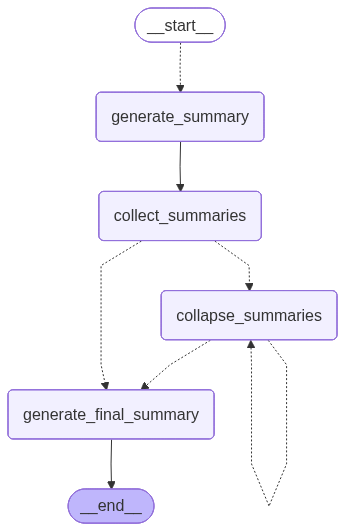

In [90]:
from IPython.display import Image
Image(summarize.get_graph().draw_mermaid_png())

In [92]:
result = await summarize.ainvoke({"contents":[doc.page_content for doc in docs]},
{'recursion_limit':10}
)

In [93]:
result.keys()

dict_keys(['contents', 'summaries', 'collapsed_summaries', 'final_summary'])

In [95]:
len(result['collapsed_summaries'])

3

In [94]:
print(result['final_summary'])

The summaries highlight recent advancements in language models and natural language processing (NLP), focusing on the LLaMA (Large Language Model Meta AI) series developed by Meta AI. This series includes models ranging from 7 billion to 65 billion parameters, trained on 1.4 trillion tokens from diverse datasets. LLaMA models demonstrate state-of-the-art performance, with LLaMA-13B outperforming GPT-3 and LLaMA-65B competing with top models like Chinchilla and PaLM. They excel in zero-shot and few-shot tasks, particularly in reading comprehension and code generation, though they also exhibit biases and generate toxic content, raising concerns about their environmental impact due to significant carbon emissions during training.

The broader research landscape includes topics such as instruction fine-tuning, scaling laws, and the development of large datasets for model training and evaluation. Various AI models, including GPT-3 and Gopher, are assessed on benchmarks, revealing trends in 

## Aysnc way

In [96]:
async for step in summarize.astream(
    {"contents":[doc.page_content for doc in docs]},
    {"recursion_limit":10}
):
    print(list(step.keys()))

['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['generate_summary']
['collect_summaries']
['collapse_summaries']
['generate_final_summary']


In [97]:
step['generate_final_summary']['final_summary']

'The summaries cover advancements in natural language processing (NLP) and the implications of AI technologies, particularly focusing on the LLaMA (Large Language Model Meta AI) series developed by Meta AI. The LLaMA models, ranging from 7 billion to 65 billion parameters, are trained on 1.4 trillion tokens from publicly available datasets and demonstrate state-of-the-art performance, often outperforming larger models like GPT-3 and competing with others such as Chinchilla and PaLM. Key architectural improvements include pre-normalization, the SwiGLU activation function, and rotary embeddings, with training optimized using the AdamW optimizer.\n\nPerformance evaluations indicate that LLaMA models excel in zero-shot and few-shot settings across various benchmarks, particularly in reading comprehension and mathematical reasoning, although they exhibit biases and generate more toxic content. The environmental impact of training these models is significant, prompting discussions on accessi